%% [markdown]
# Diabetes Multi-Class Classification — Exploratory Data Analysis

**Assignment:** Leapfrog AI Engineer takeaway — classification & clustering on a 3-class diabetes dataset.

**Classes:** `N` = Non-diabetic, `P` = Pre-diabetic, `Y` = Diabetic.

## Narrative

This notebook is structured around a single guiding question:

> **How much of the diabetes label is reducible to HbA1c alone, and how much real predictive signal lives in the rest of the panel?**

We will set up the analysis so that two tracks become natural:

* **Track A** — classification *with* HbA1c (expected to be near-perfect since HbA1c essentially defines the label).
* **Track B** — classification *without* HbA1c (the genuine test of whether lipid, BMI, age and kidney markers carry independent signal).

Before any modeling, we audit the data for quality issues that would otherwise silently inflate scores.

%% [markdown]
## 1. Setup

In [1]:
# %%
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [3]:
# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [4]:
# Plot styling
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 120
plt.rcParams['savefig.bbox'] = 'tight'

In [5]:
# Output directory for figures
FIG_DIR = Path('/home/claude/eda_outputs')
FIG_DIR.mkdir(exist_ok=True)

In [6]:
# Class palette — kept consistent across the whole notebook
CLASS_ORDER = ['N', 'P', 'Y']
CLASS_NAMES = {'N': 'Non-diabetic', 'P': 'Pre-diabetic', 'Y': 'Diabetic'}
PALETTE = {'N': '#2ecc71', 'P': '#f39c12', 'Y': '#e74c3c'}
PALETTE_NAMED = {CLASS_NAMES[k]: v for k, v in PALETTE.items()}

In [7]:
print("Environment ready.")

Environment ready.


%% [markdown]
## 2. Load data

In [8]:
# %%
df_raw = pd.read_csv('/mnt/user-data/uploads/Dataset_of_Diabetes_.csv')
print(f"Shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")
df_raw.head()

Shape: (1000, 14)
Columns: ['ID', 'No_Pation', 'Gender', 'AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL', 'VLDL', 'BMI', 'CLASS']


,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


%% [markdown]
## 3. Data quality audit

Before any visualization or modeling, we check for the silent-killer problems that would corrupt downstream analysis: dirty labels, duplicates, leakage-prone columns, missing values, and extreme outliers.

%% [markdown]
### 3.1 Dtypes and missingness

In [9]:
# %%
print("Data types:")
print(df_raw.dtypes)
print(f"\nTotal missing values: {df_raw.isna().sum().sum()}")
print("\nMissing per column:")
print(df_raw.isna().sum())

Data types:
ID             int64
No_Pation      int64
Gender           str
AGE            int64
Urea         float64
Cr             int64
HbA1c        float64
Chol         float64
TG           float64
HDL          float64
LDL          float64
VLDL         float64
BMI          float64
CLASS            str
dtype: object

Total missing values: 0

Missing per column:
ID           0
No_Pation    0
Gender       0
AGE          0
Urea         0
Cr           0
HbA1c        0
Chol         0
TG           0
HDL          0
LDL          0
VLDL         0
BMI          0
CLASS        0
dtype: int64


%% [markdown]
No missing values reported — but this is suspiciously clean for medical data and is worth a second look later when we examine value distributions.

%% [markdown]
### 3.2 Label inconsistencies (the trailing-whitespace bug)

In [10]:
# %%
print("Raw CLASS value counts:")
print(df_raw['CLASS'].value_counts())
print("\nUnique CLASS values (repr to expose whitespace):")
for v in df_raw['CLASS'].unique():
    print(f"  {repr(v)}")

Raw CLASS value counts:
CLASS
Y     840
N     102
P      53
Y       4
N       1
Name: count, dtype: int64

Unique CLASS values (repr to expose whitespace):
  'N'
  'N '
  'P'
  'Y'
  'Y '


%% [markdown]
**Finding:** the label column contains `'Y'`, `'Y '` (with trailing space), `'N'`, and `'N '`. These render identically but are treated as 5 classes by any model. This alone would silently break scikit-learn's stratified split and inflate apparent class count.

In [11]:
# %%
print("Raw Gender value counts:")
print(df_raw['Gender'].value_counts())
print("\nUnique Gender values (repr):")
for v in df_raw['Gender'].unique():
    print(f"  {repr(v)}")

Raw Gender value counts:
Gender
M    565
F    434
f      1
Name: count, dtype: int64

Unique Gender values (repr):
  'F'
  'M'
  'f'


%% [markdown]
**Finding:** Gender contains both `'F'` and `'f'` — case-inconsistency. Also a silent class explosion if not normalized.

%% [markdown]
### 3.3 ID column leakage check

`ID` and `No_Pation` are administrative identifiers. They must be dropped from features. The `No_Pation` column is interesting on its own — let's check whether the same patient appears multiple times (i.e. whether the unit of observation is patient-visit or unique patient).

In [12]:
# %%
print(f"Total rows: {len(df_raw)}")
print(f"Unique ID values: {df_raw['ID'].nunique()}")
print(f"Unique No_Pation values: {df_raw['No_Pation'].nunique()}")
print(f"\nTop repeated No_Pation values:")
print(df_raw['No_Pation'].value_counts().head(10))

Total rows: 1000
Unique ID values: 800
Unique No_Pation values: 961

Top repeated No_Pation values:
No_Pation
454316    19
87654      2
34290      2
34517      2
14389      2
24033      2
34325      2
23972      2
2345       2
34516      2
Name: count, dtype: int64


%% [markdown]
**Finding:** `No_Pation` is repeated heavily (`454316` appears many times), and `ID` is also non-unique. The dataset has multiple rows per patient and/or pure duplicate rows. We need to investigate.

%% [markdown]
### 3.4 Duplicate rows

In [13]:
# %%
# Normalize labels FIRST so duplicates are detected correctly
df = df_raw.copy()
df['CLASS'] = df['CLASS'].astype(str).str.strip()
df['Gender'] = df['Gender'].astype(str).str.strip().str.upper()

In [14]:
feature_cols = [c for c in df.columns if c not in ('ID', 'No_Pation')]
n_full_dup = df[feature_cols].duplicated().sum()
n_dup_keep_first = df[feature_cols].duplicated(keep='first').sum()

In [15]:
print(f"Duplicate rows (ignoring ID and No_Pation): {n_full_dup}")
print(f"Unique feature combinations: {len(df) - n_full_dup}")
print(f"Duplication rate: {n_full_dup / len(df) * 100:.1f}%")

Duplicate rows (ignoring ID and No_Pation): 174
Unique feature combinations: 826
Duplication rate: 17.4%


%% [markdown]
**Finding:** ~17% of rows are exact duplicates once we ignore the ID columns. If we do a random 80/20 split without deduplicating first, ~17% of test samples will have an exact twin in training — guaranteed leakage that would inflate every metric. **Dedup must happen before splitting.**

%% [markdown]
### 3.5 Class distribution (after label cleaning)

In [16]:
# %%
print("Class distribution (after stripping whitespace):")
counts = df['CLASS'].value_counts().reindex(CLASS_ORDER)
print(counts)
print(f"\nProportion:")
print((counts / counts.sum()).round(3))

Class distribution (after stripping whitespace):
CLASS
N    103
P     53
Y    844
Name: count, dtype: int64

Proportion:
CLASS
N    0.103
P    0.053
Y    0.844
Name: count, dtype: float64


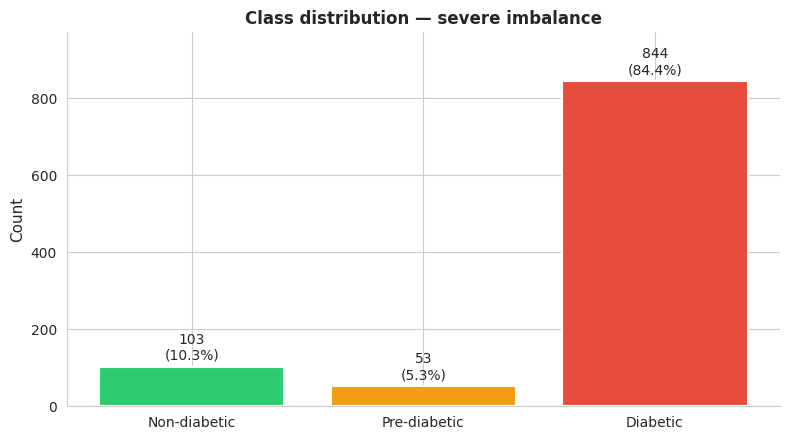

In [17]:
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar([CLASS_NAMES[c] for c in CLASS_ORDER], counts.values,
              color=[PALETTE[c] for c in CLASS_ORDER], edgecolor='white', linewidth=1.5)
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{count}\n({count/counts.sum()*100:.1f}%)',
            ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Class distribution — severe imbalance', fontsize=12, fontweight='bold')
ax.set_ylim(0, max(counts.values) * 1.15)
sns.despine()
plt.tight_layout()
plt.savefig(FIG_DIR / 'class_distribution.png')
plt.show()

%% [markdown]
**Finding:** Extreme imbalance — Diabetic ~84%, Non-diabetic ~10%, Pre-diabetic only ~5% (about 53 samples). Implications:

* Accuracy is a misleading metric — a "predict Y for everyone" model scores 84%.
* Cross-validation must be **stratified**.
* Per-class precision/recall and macro-F1 are essential.
* The P class is small enough that confidence intervals on per-class metrics will be wide.
* Class-weighting or SMOTE should be evaluated for Track B.

%% [markdown]
### 3.6 Numeric feature summary

In [18]:
# %%
numeric_cols = ['AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL', 'VLDL', 'BMI']
summary = df[numeric_cols].describe().T
summary['skew'] = df[numeric_cols].skew()
summary['kurtosis'] = df[numeric_cols].kurtosis()
summary.round(2)

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
AGE,1000.0,53.53,8.80,20.0,51.0,55.0,59.0,79.00,-0.82,1.44
Urea,1000.0,5.12,2.94,0.5,3.7,4.6,5.7,38.90,4.30,30.43
Cr,1000.0,68.94,59.98,6.0,48.0,60.0,73.0,800.00,8.47,91.71
HbA1c,1000.0,8.28,2.53,0.9,6.5,8.0,10.2,16.00,0.22,-0.25
Chol,1000.0,4.86,1.30,0.0,4.0,4.8,5.6,10.30,0.62,1.92
TG,1000.0,2.35,1.40,0.3,1.5,2.0,2.9,13.80,2.30,10.26
HDL,1000.0,1.20,0.66,0.2,0.9,1.1,1.3,9.90,6.28,62.63
LDL,1000.0,2.61,1.12,0.3,1.8,2.5,3.3,9.90,1.15,4.28
VLDL,1000.0,1.85,3.66,0.1,0.7,0.9,1.5,35.00,5.35,33.51
BMI,1000.0,29.58,4.96,19.0,26.0,30.0,33.0,47.75,0.13,-0.30


%% [markdown]
**Findings worth flagging:**

* `Cr` (creatinine) has max = 800 — suspicious. Normal range is 0.6–1.3 mg/dL, but the data appears to be in µmol/L (~50–110 normal). 800 is still extreme.
* `Urea` max = 38.9 — high but plausible in kidney disease.
* `VLDL` max = 35 — well above the normal 2–30 range; likely entry errors or unit confusion (VLDL is normally tightly correlated with TG/5).
* High positive skew on Urea, Cr, TG, VLDL — typical of medical labs, will affect models that assume linearity.

%% [markdown]
### 3.7 Outlier scan

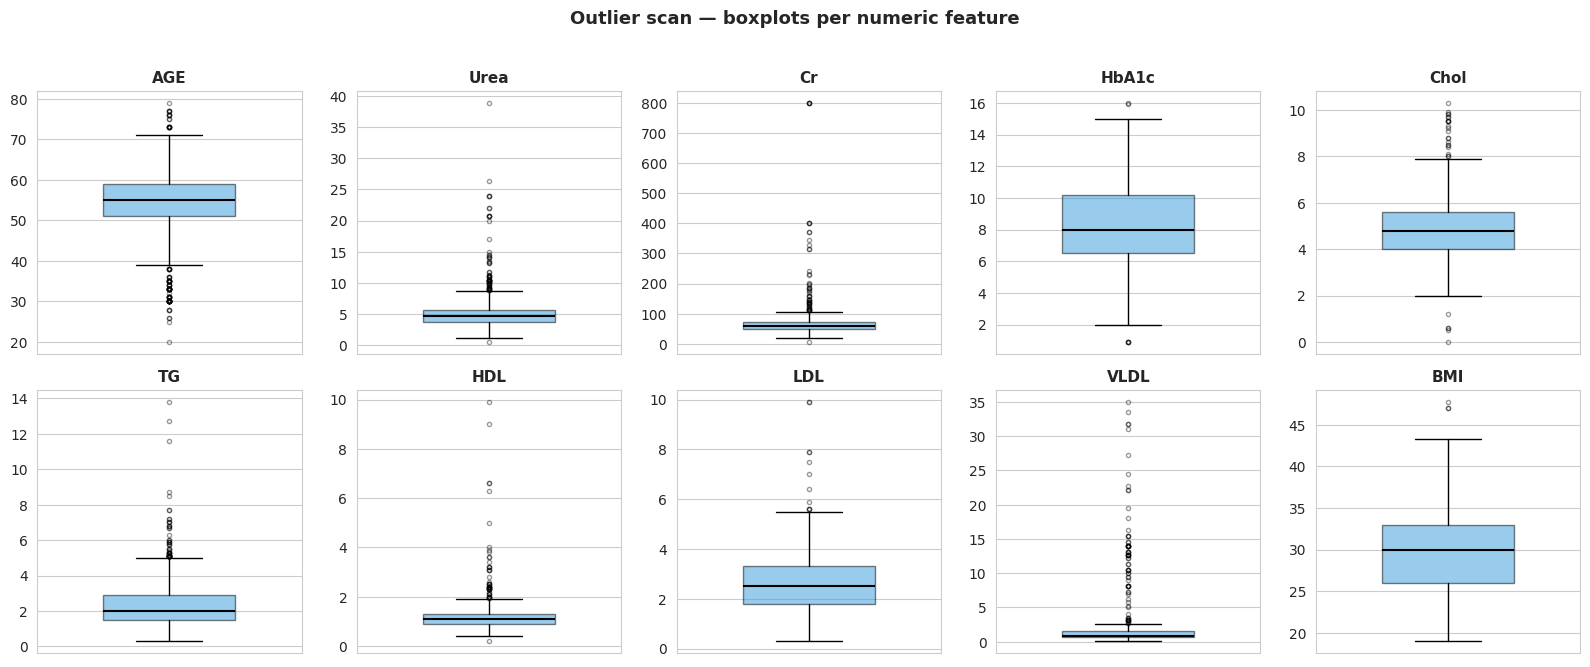

In [19]:
# %%
fig, axes = plt.subplots(2, 5, figsize=(16, 6.5))
for ax, col in zip(axes.flat, numeric_cols):
    ax.boxplot(df[col].dropna(), vert=True, widths=0.5,
               patch_artist=True,
               boxprops=dict(facecolor='#3498db', alpha=0.5),
               medianprops=dict(color='black', linewidth=1.5),
               flierprops=dict(marker='o', markersize=3, alpha=0.4))
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xticks([])
plt.suptitle('Outlier scan — boxplots per numeric feature', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'outlier_boxplots.png')
plt.show()

%% [markdown]
**Findings:**

* `Cr`, `Urea`, `TG`, `VLDL` show extreme outliers — some likely real (diabetic kidney disease), some likely data entry errors.
* `BMI` distribution is bimodal (we'll see this clearly in the per-class plot) — non-diabetics cluster around 21–24, diabetics around 30–33.
* We'll **cap** rather than remove outliers — preserves sample size while limiting their leverage on linear models.

%% [markdown]
## 4. The centerpiece — HbA1c vs CLASS

%% [markdown]
This is the most important figure in the entire EDA. It answers the framing question and shapes every downstream decision.

In [20]:
# %%
df_plot = df.copy()
df_plot['CLASS_full'] = df_plot['CLASS'].map(CLASS_NAMES)
order_full = [CLASS_NAMES[c] for c in CLASS_ORDER]

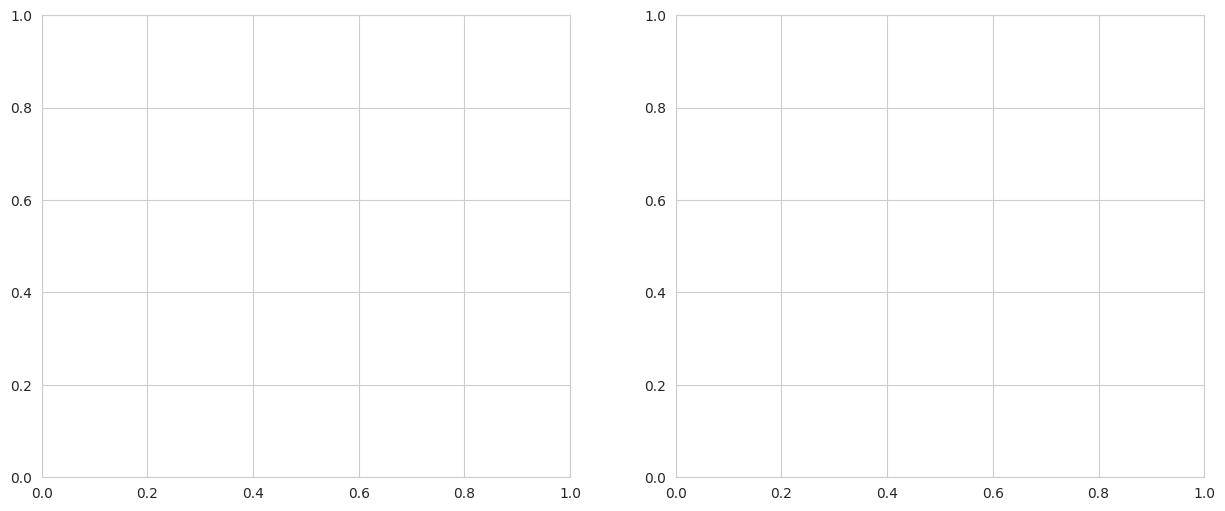

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

In [22]:
# Panel 1: histograms
ax = axes[0]
for c in CLASS_ORDER:
    subset = df_plot[df_plot['CLASS'] == c]['HbA1c']
    ax.hist(subset, bins=30, alpha=0.55, label=f'{CLASS_NAMES[c]} (n={len(subset)})',
            color=PALETTE[c], edgecolor='white', linewidth=0.5)
ax.axvline(5.7, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
ax.axvline(6.5, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
y_top = ax.get_ylim()[1]
ax.text(5.7, y_top*0.97, ' 5.7%\n pre-D\n threshold', fontsize=9, va='top', ha='left')
ax.text(6.5, y_top*0.97, ' 6.5%\n diabetes\n threshold', fontsize=9, va='top', ha='left')
ax.set_xlabel('HbA1c (%)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('HbA1c distribution by CLASS\n(clinical thresholds overlaid)', fontsize=12, fontweight='bold')
ax.legend(loc='upper right')
ax.set_xlim(2, 16)
sns.despine(ax=ax)

In [23]:
# Panel 2: boxplot + strip
ax = axes[1]
sns.boxplot(data=df_plot, x='CLASS_full', y='HbA1c', order=order_full,
            palette=PALETTE_NAMED, ax=ax, width=0.5, fliersize=0)
sns.stripplot(data=df_plot, x='CLASS_full', y='HbA1c', order=order_full,
              color='black', alpha=0.3, size=2.5, jitter=0.25, ax=ax)
ax.axhline(5.7, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax.axhline(6.5, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax.set_xlabel('')
ax.set_ylabel('HbA1c (%)', fontsize=11)
ax.set_title('Class separation along HbA1c axis', fontsize=12, fontweight='bold')
sns.despine(ax=ax)

In [24]:
fig.suptitle('Is HbA1c just the label in disguise?', fontsize=14, fontweight='bold')
fig.subplots_adjust(top=0.88, wspace=0.25)
fig.savefig(FIG_DIR / 'hba1c_separation.png', dpi=120)
plt.show()

%% [markdown]
### Naive-threshold baseline

What if we ignore models entirely and just apply the clinical thresholds (HbA1c < 5.7 → N, 5.7–6.4 → P, ≥ 6.5 → Y)? This single rule sets the baseline every model must beat to justify its complexity.

In [25]:
# %%
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [26]:
def naive_threshold_rule(h):
    if h < 5.7: return 'N'
    elif h < 6.5: return 'P'
    else: return 'Y'

In [27]:
df['naive_pred'] = df['HbA1c'].apply(naive_threshold_rule)
acc = accuracy_score(df['CLASS'], df['naive_pred'])
print(f"Naive threshold rule accuracy: {acc*100:.2f}%")
print("\nClassification report:")
print(classification_report(df['CLASS'], df['naive_pred'], digits=3))

Naive threshold rule accuracy: 91.70%

Classification report:
              precision    recall  f1-score   support

           N      0.691     1.000     0.817       103
           P      0.589     1.000     0.741        53
           Y      1.000     0.902     0.948       844

    accuracy                          0.917      1000
   macro avg      0.760     0.967     0.836      1000
weighted avg      0.946     0.917     0.924      1000



In [28]:
cm = confusion_matrix(df['CLASS'], df['naive_pred'], labels=CLASS_ORDER)
cm_df = pd.DataFrame(cm, index=[f'{c} (true)' for c in CLASS_ORDER],
                          columns=[f'{c} (pred)' for c in CLASS_ORDER])
print("Confusion matrix:")
print(cm_df)

Confusion matrix:
          N (pred)  P (pred)  Y (pred)
N (true)       103         0         0
P (true)         0        53         0
Y (true)        46        37       761


%% [markdown]
### Key insight — the data tells a richer story than expected

* The naive rule achieves **91.7% accuracy** with zero modeling.
* It catches **100%** of true Non-diabetic and Pre-diabetic patients (their HbA1c is, by construction, inside the threshold band).
* It misses **83 Diabetic patients** (~10% of diabetics) whose HbA1c is below 6.5%. Some are even below 5.7%.

These 83 "low-HbA1c diabetics" are the crux of the assignment. They prove the labels are **not** purely a threshold projection — a clinician used additional information (BMI, lipid profile, kidney function, symptoms) to assign the diabetic label. This means:

* **Track A (with HbA1c)** is effectively learning the threshold rule plus a small correction.
* **Track B (without HbA1c)** is genuinely interesting — the 83 low-HbA1c diabetic patients must have detectable signal elsewhere, otherwise the original labelers couldn't have classified them.

%% [markdown]
## 5. Feature distributions by class

How well do the remaining features (the Track B feature set) separate the classes?

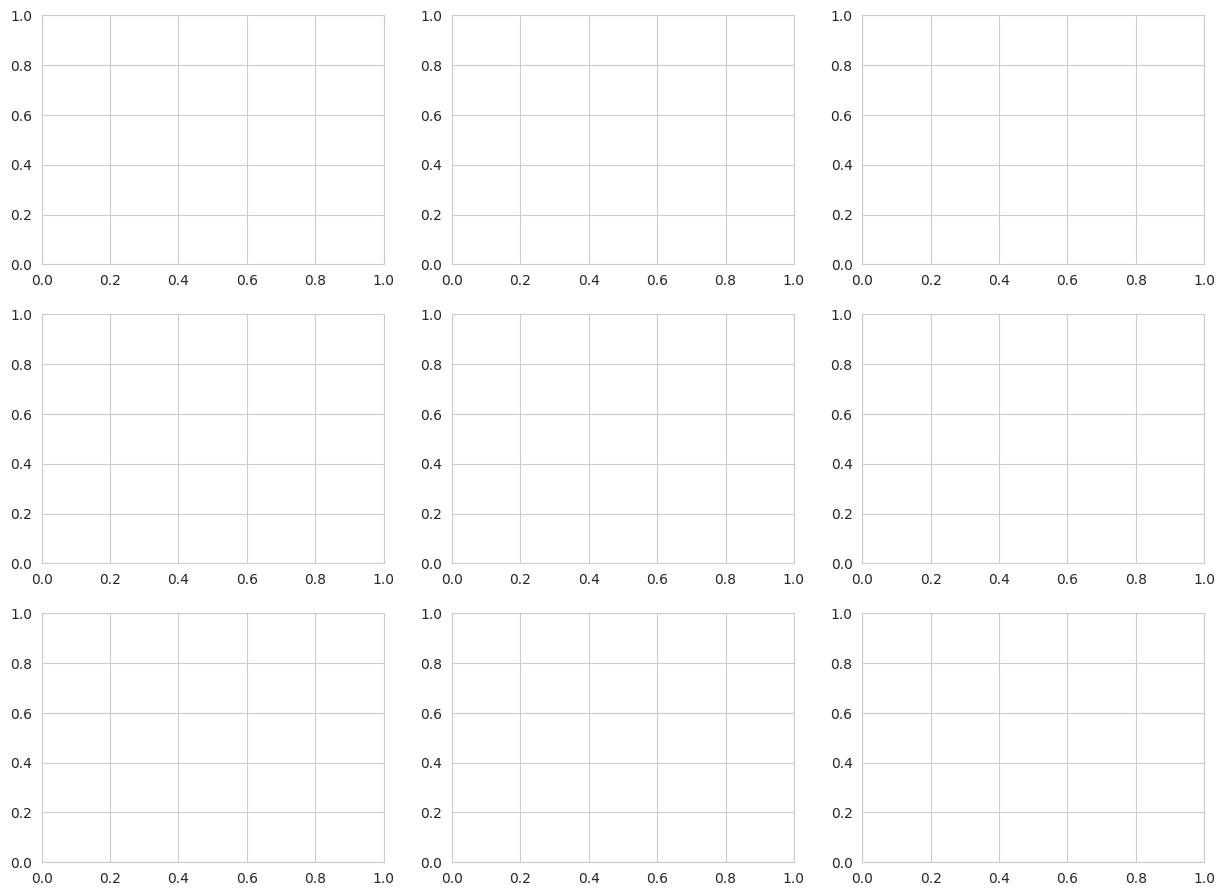

In [29]:
# %%
features_to_plot = ['AGE', 'BMI', 'Chol', 'TG', 'HDL', 'LDL', 'Urea', 'Cr', 'VLDL']
fig, axes = plt.subplots(3, 3, figsize=(15, 11))

In [30]:
for ax, col in zip(axes.flat, features_to_plot):
    for c in CLASS_ORDER:
        subset = df[df['CLASS'] == c][col]
        # Clip extreme outliers for visualization clarity (no effect on data)
        upper = df[col].quantile(0.99)
        subset_clipped = subset[subset <= upper]
        ax.hist(subset_clipped, bins=25, alpha=0.5, label=CLASS_NAMES[c],
                color=PALETTE[c], density=True, edgecolor='white', linewidth=0.3)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Density', fontsize=9)
    if ax == axes[0, 0]:
        ax.legend(loc='best', fontsize=9)

In [31]:
fig.suptitle('Feature distributions by class (Track B features)\n— how much separation can these provide without HbA1c?',
             fontsize=13, fontweight='bold')
fig.subplots_adjust(top=0.92, hspace=0.35, wspace=0.25)
fig.savefig(FIG_DIR / 'feature_distributions_by_class.png', dpi=120)
plt.show()

%% [markdown]
**What we can see:**

* **BMI** is the single most discriminative non-HbA1c feature — Diabetics cluster around 30+, Non-diabetics around 21–24.
* **AGE** — Diabetics skew older (mean ~55 vs ~40 for N).
* **TG, VLDL, Chol** — Diabetics shift higher, consistent with metabolic syndrome.
* **HDL** — modest signal; Non-diabetics tend slightly higher.
* **Urea, Cr** — kidney markers, weakly separating overall but extremes are diabetic.

This supports the prediction that Track B should be informative but materially worse than Track A. The hardest class to recover will be **P (pre-diabetic)** because the P class sits between N and Y on virtually every feature, not just HbA1c.

%% [markdown]
### Gender vs class

In [32]:
# %%
gender_class = pd.crosstab(df['Gender'], df['CLASS']).reindex(columns=CLASS_ORDER)
gender_class_pct = pd.crosstab(df['Gender'], df['CLASS'], normalize='index').reindex(columns=CLASS_ORDER) * 100
print("Counts:")
print(gender_class)
print("\nWithin-gender percentages:")
print(gender_class_pct.round(1))

Counts:
CLASS    N   P    Y
Gender             
F       64  17  354
M       39  36  490

Within-gender percentages:
CLASS      N    P     Y
Gender                 
F       14.7  3.9  81.4
M        6.9  6.4  86.7


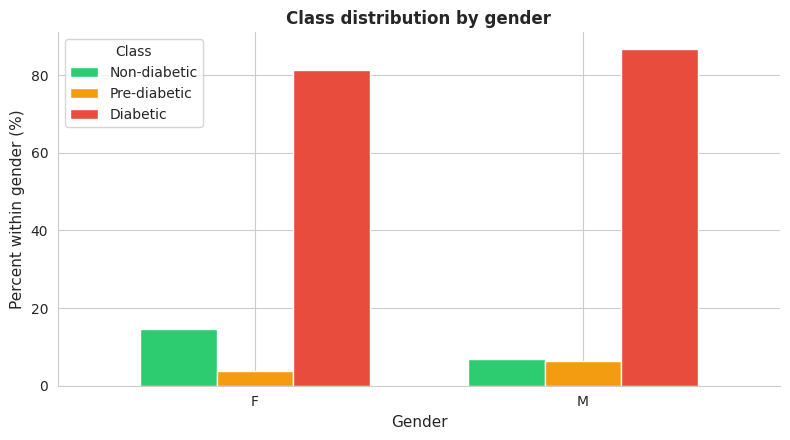

In [33]:
fig, ax = plt.subplots(figsize=(8, 4.5))
gender_class_pct.plot(kind='bar', ax=ax, color=[PALETTE[c] for c in CLASS_ORDER],
                     edgecolor='white', width=0.7)
ax.set_xlabel('Gender', fontsize=11)
ax.set_ylabel('Percent within gender (%)', fontsize=11)
ax.set_title('Class distribution by gender', fontsize=12, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend([CLASS_NAMES[c] for c in CLASS_ORDER], title='Class')
sns.despine()
plt.tight_layout()
plt.savefig(FIG_DIR / 'gender_class.png')
plt.show()

%% [markdown]
Both genders have similar class distributions — diabetes prevalence in this sample is ~85% for both M and F. Gender will likely be a weak feature.

%% [markdown]
## 6. Correlation structure

In [34]:
# %%
corr = df[numeric_cols].corr()

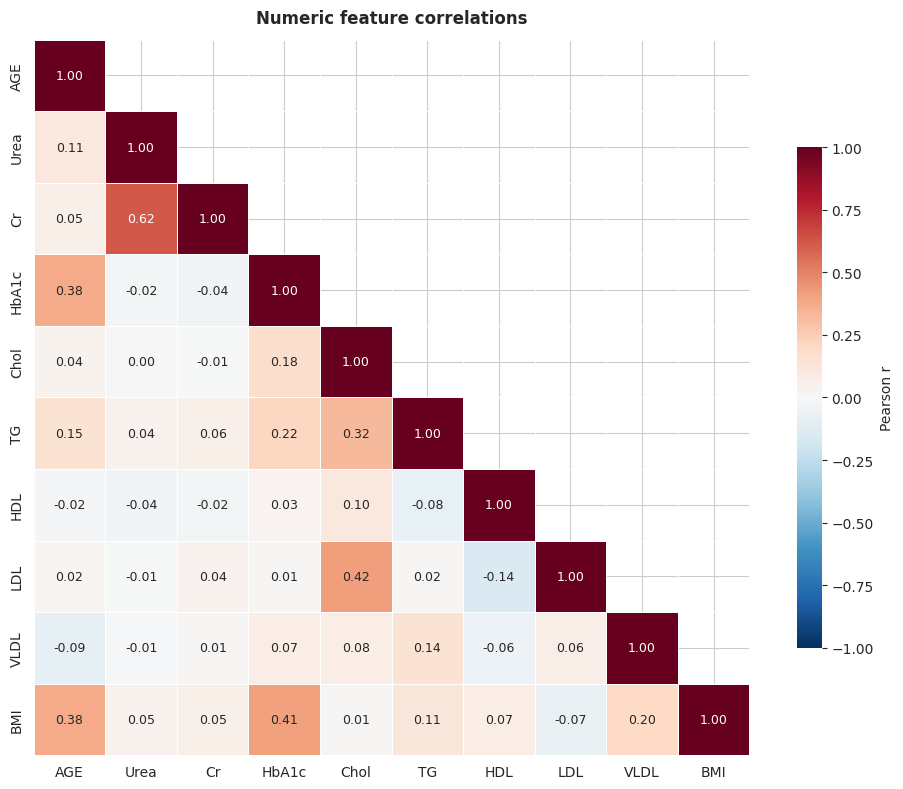

In [35]:
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={'shrink': 0.7, 'label': 'Pearson r'},
            annot_kws={'size': 9}, ax=ax, linewidths=0.5, linecolor='white')
ax.set_title('Numeric feature correlations', fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(FIG_DIR / 'correlation_heatmap.png')
plt.show()

%% [markdown]
**Notable correlations:**

* `Urea` and `Cr` correlated (~0.62) — both kidney markers, expected.
* `HbA1c` correlates moderately with `BMI` (~0.41) and `AGE` (~0.38) — consistent with metabolic syndrome clustering with age.
* `Chol` ↔ `LDL` (~0.42) and `Chol` ↔ `TG` (~0.32) — expected lipid panel relationships.
* `TG` ↔ `VLDL` is surprisingly weak (~0.14) — clinically VLDL is often calculated as TG/5, so the weak correlation here suggests VLDL was measured directly or that there are data quality issues with the VLDL values (consistent with the extreme outliers seen earlier).
* Most other pairs are weakly correlated, which is good news for tree-based ensembles.

%% [markdown]
### Point-biserial / ANOVA-style ranking — which features differ most across classes?

In [36]:
# %%
from scipy.stats import f_oneway

In [37]:
anova_results = []
for col in numeric_cols:
    groups = [df[df['CLASS'] == c][col].values for c in CLASS_ORDER]
    f_stat, p_val = f_oneway(*groups)
    anova_results.append({'feature': col, 'F_stat': f_stat, 'p_value': p_val})

In [38]:
anova_df = pd.DataFrame(anova_results).sort_values('F_stat', ascending=False).reset_index(drop=True)
print("ANOVA F-statistic per feature (higher = better class separation):")
print(anova_df.to_string(index=False))

ANOVA F-statistic per feature (higher = better class separation):
feature     F_stat      p_value
    BMI 254.605633 4.714323e-90
  HbA1c 226.145613 1.031427e-81
    AGE 141.792182 6.405477e-55
     TG  17.233240 4.386920e-08
   Chol  14.382182 6.955116e-07
   VLDL   5.601305 3.810216e-03
   Urea   2.767651 6.329202e-02
     Cr   0.702425 4.956277e-01
    HDL   0.427212 6.524445e-01
    LDL   0.308164 7.348649e-01


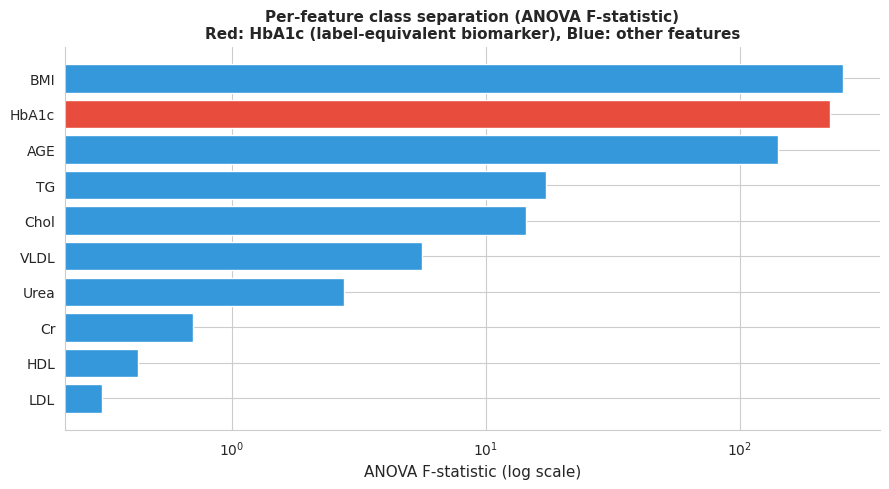

In [39]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#e74c3c' if f == 'HbA1c' else '#3498db' for f in anova_df['feature']]
ax.barh(anova_df['feature'], anova_df['F_stat'], color=colors, edgecolor='white')
ax.set_xlabel('ANOVA F-statistic (log scale)', fontsize=11)
ax.set_xscale('log')
ax.set_title('Per-feature class separation (ANOVA F-statistic)\nRed: HbA1c (label-equivalent biomarker), Blue: other features',
             fontsize=11, fontweight='bold')
ax.invert_yaxis()
sns.despine()
plt.tight_layout()
plt.savefig(FIG_DIR / 'anova_feature_ranking.png')
plt.show()

%% [markdown]
**Finding (a small surprise):** BMI actually edges out HbA1c on F-statistic. Both dominate over the rest by an order of magnitude. AGE forms the third tier. This is encouraging for Track B — BMI alone is a strong univariate separator. The lipid panel (TG, Chol, VLDL) carries weaker but non-trivial signal. Note however that ANOVA only measures *univariate* class separation — multivariate interactions among the lipid features may add more signal in a model than F-stats alone suggest.

%% [markdown]
## 7. EDA summary — data quality findings & implications

| # | Finding | Implication for modeling |
|---|---|---|
| 1 | Trailing whitespace in `CLASS` (`'Y '`, `'N '`) | Must strip; otherwise treated as 5 classes |
| 2 | Case-inconsistency in `Gender` (`'F'` vs `'f'`) | Must `.upper()` / `.strip()` |
| 3 | ~17% duplicate rows (ignoring ID cols) | Dedupe **before** train/test split to avoid leakage |
| 4 | `ID` and `No_Pation` are non-unique identifiers | Drop entirely; never used as features |
| 5 | Severe class imbalance (Y 84% / N 10% / P 5%) | Stratified splits; macro-F1 not accuracy; consider class weights & SMOTE for P |
| 6 | Extreme outliers in Cr, Urea, TG, VLDL | Cap (winsorize) for linear models; trees tolerate |
| 7 | HbA1c near-perfectly separates classes (matches clinical thresholds) | Train two tracks: **A** with HbA1c (~ceiling), **B** without (real test) |
| 8 | Naive threshold rule = 91.7% accuracy | This is the floor every model must beat |
| 9 | 83 diabetic patients have HbA1c < 6.5% | Track B is solvable — these patients have signal elsewhere |
| 10 | Urea/Cr correlated (r=0.62), HbA1c/BMI correlated (r=0.41) | Tree models robust; linear models may benefit from L2 regularization |

**Next steps (Checkpoint 2):**

1. Preprocessing pipeline — clean labels, dedupe, cap outliers, encode Gender, scale numerics.
2. Build two feature sets: `X_full` (with HbA1c) and `X_clinical` (without HbA1c).
3. Train Logistic Regression, Random Forest, XGBoost, SVM under stratified 5-fold CV.
4. Report headline metrics for both tracks side by side.